In [14]:
!pip install opencv-python


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import cv2
import numpy as np
import pathlib
import matplotlib.pyplot as plt

class ProcesadorPDI:
    """
    Clase inmutable para procesamiento de imágenes usando OpenCV y NumPy.
    """
    def __init__(self, imagen, titulo="Imagen"):
        if isinstance(imagen, (str, pathlib.Path)):
            self.tensor = cv2.imread(str(imagen), cv2.IMREAD_GRAYSCALE)
        else:
            self.tensor = imagen
        self.titulo = titulo


    def to_negative(self) -> "ProcesadorPDI":
        """Aplica el negativo usando operaciones bit a bit ultrarrápidas de OpenCV."""
        tensor_neg = cv2.bitwise_not(self.tensor)
        return ProcesadorPDI(tensor_neg, titulo=f"Negativo de {self.titulo}")

    def gamma_transform(self, gamma: float) -> "ProcesadorPDI":
        """
        Aplica transformación Gamma usando una Look-Up Table (LUT) para evitar
        hacer ciclos sobre cada píxel.
        """
        # 1. Construimos una tabla de equivalencias con NumPy
        inv_gamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** inv_gamma) * 255 
                          for i in np.arange(0, 256)]).astype("uint8")
        
        # 2. OpenCV mapea la matriz completa instantáneamente
        tensor_gamma = cv2.LUT(self.tensor, table)
        return ProcesadorPDI(tensor_gamma, titulo=f"Gamma (g={gamma})")

    def binarize(self, umbral: int = 127) -> "ProcesadorPDI":
        """Binarizado global clásico."""
        # OpenCV devuelve dos valores: el umbral usado y la imagen binarizada
        _, tensor_bin = cv2.threshold(self.tensor, umbral, 255, cv2.THRESH_BINARY)
        return ProcesadorPDI(tensor_bin, titulo=f"Binario (th={umbral})")

    def show(self):
        """Muestra la imagen usando las ventanas de OpenCV."""
        cv2.imshow(self.titulo, self.tensor)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        return self

    def show_jupyter(self, figsize=(6, 6)):
        """Muestra la imagen inline en Jupyter usando matplotlib."""
        plt.figure(figsize=figsize)
        plt.imshow(self.tensor, cmap='gray')
        plt.title(self.titulo)
        plt.axis('off')
        plt.show()
        return self
    
    def plot_histogram(self) -> "ProcesadorPDI":
        """Calcula y grafica el histograma de la imagen actual."""
        hist = cv2.calcHist([self.tensor], [0], None, [256], [0, 256])
        
        plt.figure(figsize=(5, 4))
        plt.title(f"Histograma de {self.titulo}")
        plt.xlabel("Intensidad del píxel (0-255)")
        plt.ylabel("Cantidad de píxeles")
        
        plt.plot(hist, color='black')
        plt.fill_between(range(256), hist.flatten(), color='red', alpha=0.5)
        
        plt.xlim([0, 256])
        plt.grid(alpha=0.3, linestyle='--')
        
        plt.show()
        
        return self


In [66]:
import pathlib

ruta = pathlib.Path.cwd() / "imagenes"

In [67]:
def cargar_imagen(nombre_archivo):
    """Carga una imagen desde el directorio 'imagenes'."""
    return ruta / nombre_archivo

# Ejercicio 1

a) Una radiografía fue tomada para diagnosticar en un paciente problemas en la columna vertebral. Por
un error del operador de la máquina de rayos X, los huesos no aparecen de manera clara. Como el
paciente no puede ser expuesto nuevamente, debido a que ya se ha tomado demasiadas radiografías
para un año, se le pide a usted que procese dicha radiografía para mejorar la definición de los huesos.
Explique cómo seleccionó el procesamiento aplicado.


    

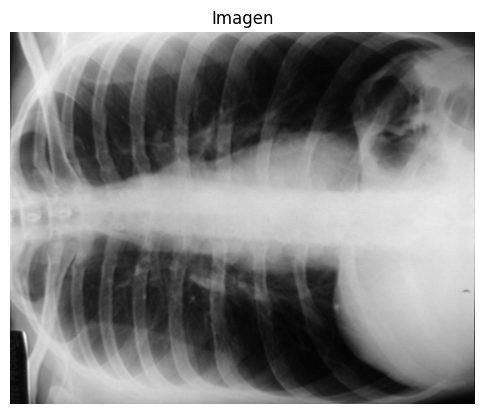

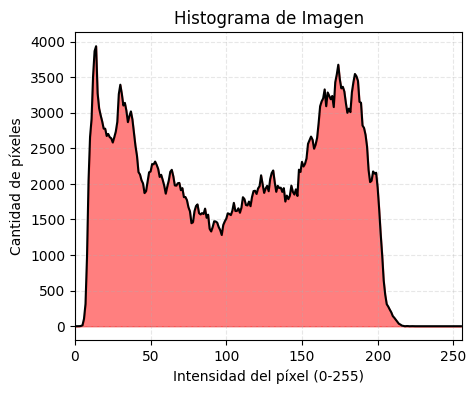

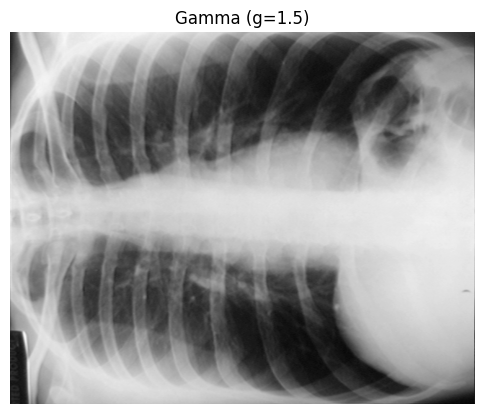

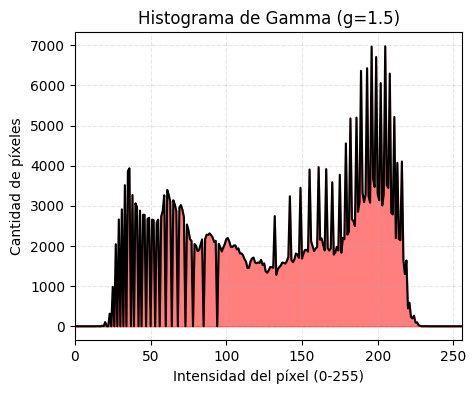

In [68]:
imagen = ProcesadorPDI(cargar_imagen('toraxP.bmp'))
imagen.show_jupyter()
imagen.plot_histogram()
imagen_columna = imagen.gamma_transform(1.5)
imagen_columna.show_jupyter()
imagen_columna.plot_histogram()

b) Una vez que ha regresado el paciente con su radiografía al consultorio, el médico sospecha de
problemas en el pulmón y el hígado al enterarse que el paciente consume alcohol y tabaco en
cantidades no recomendables. ¿Podría usted mejorar la radiografía para facilitar el diagnóstico en este
caso? Explique cómo seleccionó el procesamiento aplicado.

c) Después de discutir sus malos hábitos, el paciente comenta de cierto dolor en la articulación de la
cadera, justo en la parte alta de la pierna derecha. Mejore la imagen de tal forma que sea mas clara esta
articulación. Explique cómo seleccionó el procesamiento aplicado.